# Machine Intelligence I
### Sheet 7
##### Group members: Abed Al Karim Taha, Rezwana Hussainzada, Salva Vali zadeh
___

**Exercise H7.1: Training data**
*(a):* Create a scatter plot of all 120 samples, using different colors/markers for the two classes.

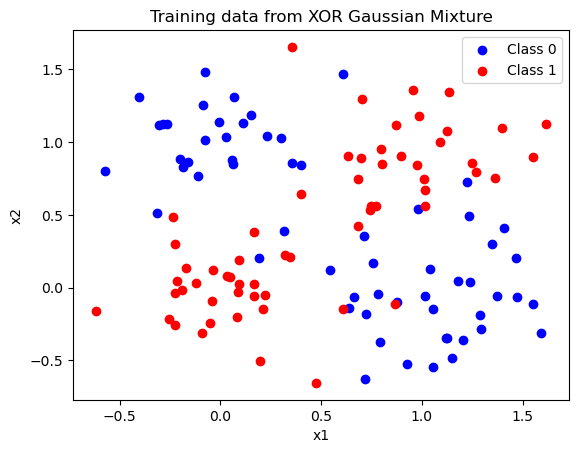

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
sigma2 = 0.1
sigma = np.sqrt(sigma2)

mu1 = np.array([0, 1])
mu2 = np.array([1, 0])
mu3 = np.array([0, 0])
mu4 = np.array([1, 1])

def sample(muA, muB, n):
    X = []
    for _ in range(n):
        if np.random.rand() < 0.5:
            X.append(muA + sigma * np.random.randn(2))
        else:
            X.append(muB + sigma * np.random.randn(2))
    return np.array(X)

X0 = sample(mu1, mu2, 60)
X1 = sample(mu3, mu4, 60)

X = np.vstack([X0, X1])
y = np.array([0]*60 + [1]*60)


plt.scatter(X0[:,0], X0[:,1], label='Class 0', color='blue')
plt.scatter(X1[:,0], X1[:,1], label='Class 1', color='red')
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training data from XOR Gaussian Mixture")
plt.show()


**Exercise H7.2: k nearest neighbors (kNN)**

*(a)* Plot the training patterns and the decision boundary (e.g. using a contour plot or a high-resolution image of )1 in input space for $k = 1, 3, 5$. What do you observe?

In [9]:
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, accuracy_score


def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, x_query, k):
    distances = [euclidean_distance(x_query, x) for x in X_train]

    nearest_indices = np.argsort(distances)[:k]

    nearest_labels = y_train[nearest_indices]

    vote = Counter(nearest_labels).most_common(1)[0][0]

    return vote


def knn_predict_batch(X_train, y_train, X_query, k):
    return np.array([knn_predict(X_train, y_train, x, k) for x in X_query])

y_pred1 = knn_predict_batch(X, y, X, k=1)
print("Accuracy for k = 1:", accuracy_score(y, y_pred1))
print("Confusion Matrix for k = 1:\n", confusion_matrix(y, y_pred1))


y_pred3 = knn_predict_batch(X, y, X, k=3)
print("\nAccuracy for k = 3:", accuracy_score(y, y_pred3))
print("Confusion Matrix for k = 3:\n", confusion_matrix(y, y_pred3))

y_pred5 = knn_predict_batch(X, y, X, k=5)
print("\nAccuracy for k = 5:", accuracy_score(y, y_pred5))
print("Confusion Matrix for k = 5:\n", confusion_matrix(y, y_pred5))

Accuracy for k = 1: 1.0
Confusion Matrix for k = 1:
 [[60  0]
 [ 0 60]]

Accuracy for k = 3: 0.9
Confusion Matrix for k = 3:
 [[53  7]
 [ 5 55]]

Accuracy for k = 5: 0.8916666666666667
Confusion Matrix for k = 5:
 [[54  6]
 [ 7 53]]


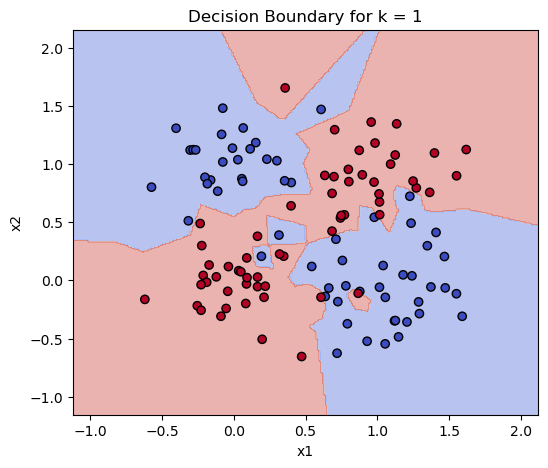

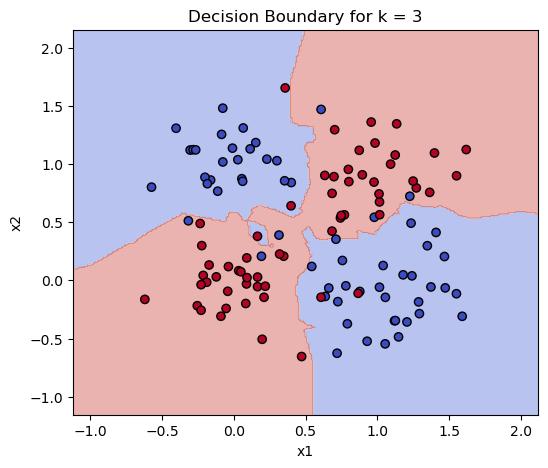

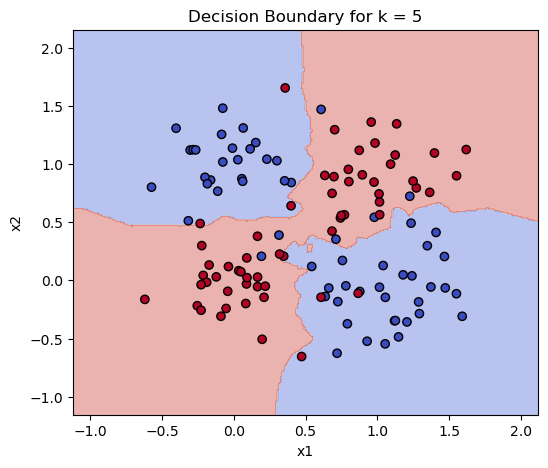

In [12]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, k):

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = knn_predict_batch(X, y, grid_points, k)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')

    plt.title(f"Decision Boundary for k = {k}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(X, y, k=1)
plot_decision_boundary(X, y, k=3)
plot_decision_boundary(X, y, k=5)

k = 1: The decision boundary is very complex. Almost every training sample creates itd own small dedicated region around it. When only one nearst neighbor is considered, each training sample can determine the final decision for points around it. This causes the model to follow the training data very closely, and even the smallest change in the data can alter the decision boundary. The model is sensitive to noise and individual samples, and it is possible to be over_fitted.

k = 3: The boundaries become somewhat smoother and more regular. Class regions appear larger and more connected. Now the decision is based on the majority vote of 3 nearest neighbors instead of just 1. This reduces the influence of a noisy point or outlier because if there is a noisy point, the other two neighbors will vote differently, correcting the decision.

k = 5: The boundaries are very smooth and regular, and class regions are large and well-formed. With a larger k, the decision is based on a bigger group of samples. The influence of each individual sample decreases, and instead of following small details in the data, the model captures the overall pattern of the data distribution.

---

**Exercise H7.3: “Parzen window” classifier**

*(a)* Plot the training patterns and the decision boundary (e.g. using a contour plot or a high-resolution image of equidistant query points) in input space for Gaussian window functions parameterized with the variances $σ^2_κ= 0.5, 0.1 and 0.01$.
*(b)* Add 60 new data points from a third class centered on $˜μ = (0.5, 0.5)^⊤$ with variance $˜σ^2 = 0.05$. Rerun the kNN and Parzen-window classification. Plot the classification
boundaries as above and compare them with your previous results.

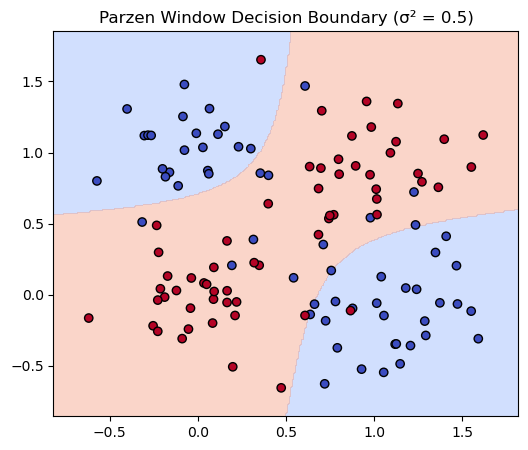

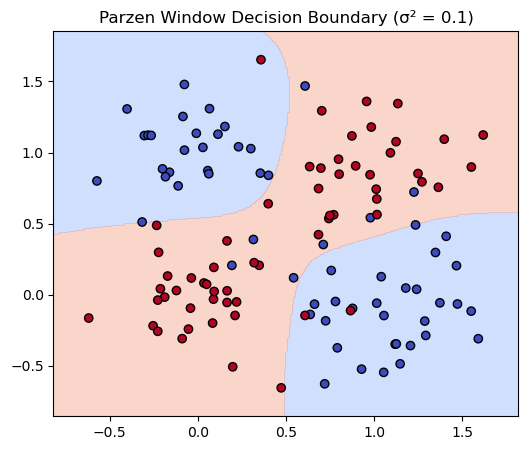

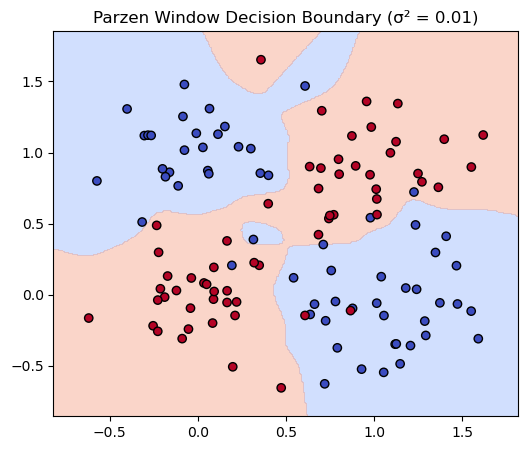

In [22]:
def gaussian_kernel(x, x_train, sigma2):
    dist2 = np.sum((x - x_train)**2, axis=1)
    return np.exp(-dist2 / (2 * sigma2))

def parzen_predict(X_train, y_train, x_query, sigma2):
    weights = gaussian_kernel(x_query, X_train, sigma2)

    classes = np.unique(y_train)
    scores = [weights[y_train == c].sum() for c in classes]
    return classes[np.argmax(scores)]


def parzen_predict_batch(X_train, y_train, X_query, sigma2):
    return np.array([parzen_predict(X_train, y_train, x, sigma2) for x in X_query])

def plot_parzen_boundary(X, y, sigma2, title=None):
    x_min, x_max = X[:,0].min() - 0.2, X[:,0].max() + 0.2
    y_min, y_max = X[:,1].min() - 0.2, X[:,1].max() + 0.2

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = parzen_predict_batch(X, y, grid, sigma2)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.4, levels=[-0.5, 0.5, 1.5], cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(f"Parzen Window Decision Boundary (σ² = {sigma2})")
    plt.show()

plot_parzen_boundary(X, y, sigma2=0.5)
plot_parzen_boundary(X, y, sigma2=0.1)
plot_parzen_boundary(X, y, sigma2=0.01)



*Effect of $σ^²$ on the Decision Boundary*:

$\sigma^2 = 0.5$: The window is wide → each point influences even distant areas. Boundaries become smooth and continuous. It may miss fine details of the classes.

$\sigma^2 = 0.1$: The window is narrower → nearby points have more weight. Boundaries are balanced: relatively smooth but still somewhat flexible.

$\sigma^2 = 0.01$: The window is very narrow → almost only very close points contribute. The model is sensitive to individual points and noise, which may lead to overfitting.

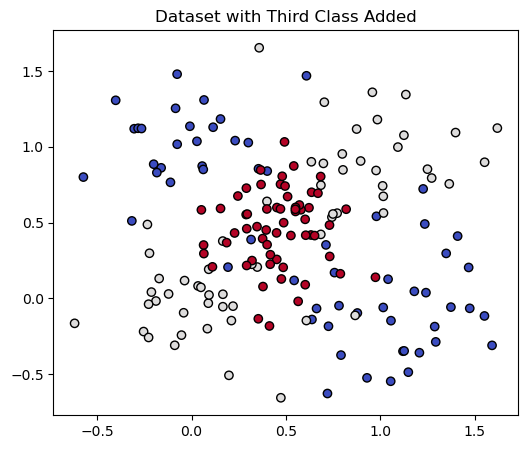

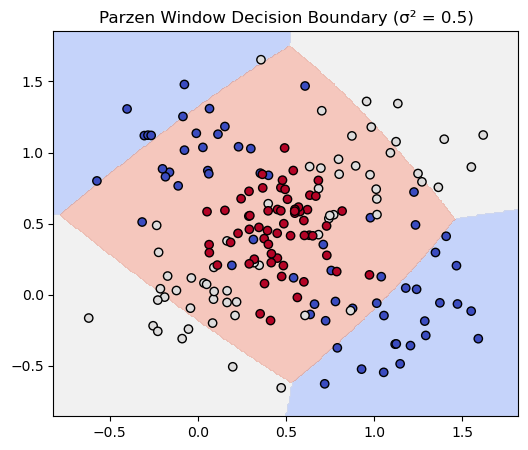

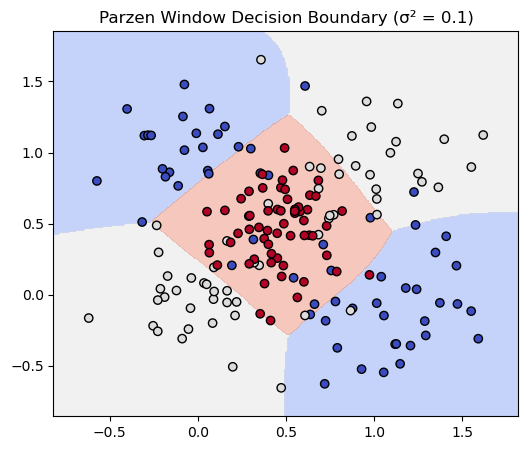

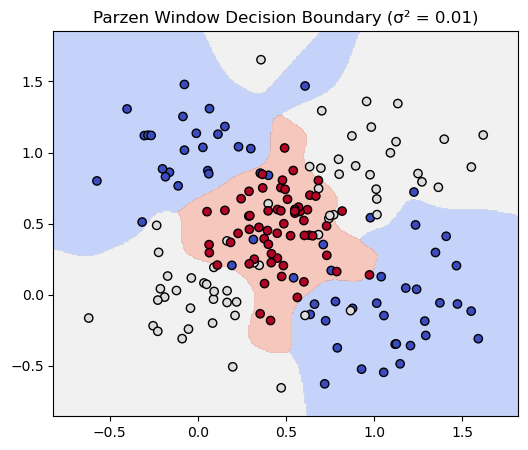

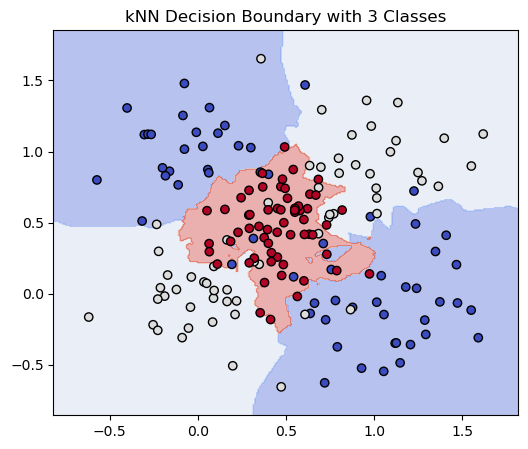

In [24]:
from sklearn.neighbors import KNeighborsClassifier

mu3 = np.array([0.5, 0.5])
sigma2_new = 0.05

new_data = np.random.normal(mu3, np.sqrt(sigma2_new), (60, 2))
new_labels = np.full(60, 2)

X3 = np.vstack([X, new_data])
y3 = np.hstack([y, new_labels])

plt.figure(figsize=(6,5))
plt.scatter(X3[:,0], X3[:,1], c=y3, cmap='coolwarm', edgecolor='k')
plt.title("Dataset with Third Class Added")
plt.show()

def plot_parzen_boundary(X, y, sigma2, title=None):
    x_min, x_max = X[:,0].min() - 0.2, X[:,0].max() + 0.2
    y_min, y_max = X[:,1].min() - 0.2, X[:,1].max() + 0.2

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = parzen_predict_batch(X, y, grid, sigma2)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.4, levels=[-0.5, 0.5, 1.5, 2.5], cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(f"Parzen Window Decision Boundary (σ² = {sigma2})")
    plt.show()

plot_parzen_boundary(X3, y3, sigma2=0.5)
plot_parzen_boundary(X3, y3, sigma2=0.1)
plot_parzen_boundary(X3, y3, sigma2=0.01)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X3, y3)

def plot_knn_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 0.2, X[:,0].max() + 0.2
    y_min, y_max = X[:,1].min() - 0.2, X[:,1].max() + 0.2

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(title)
    plt.show()

plot_knn_boundary(knn, X3, y3, "kNN Decision Boundary with 3 Classes")



We add the third class centered at (0.5, 0.5), this class is located at the place between class 0 and 1. Let's examine the decision boundary for kNN and Parzen Window with $\sigma^2 = 0.5, 0.1, 0.01$ after adding the third class. Adding a new class can help us to understand which method can adjust itself better with new data set? and what is the role of $\sigma^2$, which method may be overfitted or underfitted?

The new class push the old decision boundaries aside and force both classes 0 and 1 to give up part of their original space. For $\sigma^2 = 0.5$, because the window is wide, the third class influences a large region of the feature space. The boundaries become very smooth and soft, forming three broad regions. The third class takes over most of the central part of the plane. The algorithm becomes less sensitive to individual points, but the overall boundaries shift significantly. For $\sigma=0.1$, The third class still affects the boundary, but its effect is less than when $\sigma = 0.5$, however, the central region belonging to the third class becomes clearly visible. When $\sigma = 0.01$ the method becomes very sensitive. It is more sensitive to the details of the dataset, and it can be overfitted.

Finally, kNN produced sharp and angular boundaries between three classes. It is more sensitive than Parzen. Because kNN makes decisions based on a small number of the nearest points (if we add new points (like the new third class), the nearest neighbors change immediately.), while Parzen uses all points and smooths their influence.

---

**Exercise H7.4: RBF networks**

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

def rbf(x, t, sigma):
    return np.exp(-np.linalg.norm(x - t)**2 / (2*sigma**2))

def build_Phi(X, centers, sigma):
    K = len(centers)
    p = X.shape[0]
    Phi = np.ones((K+1, p))
    for i, t in enumerate(centers):
        Phi[i+1, :] = np.array([rbf(x, t, sigma) for x in X])
    return Phi

def compute_weights(Phi, y):
    return np.linalg.inv(Phi @ Phi.T) @ Phi @ y


def predict_rbf(X, centers, sigma, w):
    p = X.shape[0]
    K = len(centers)
    Phi = build_Phi(X, centers, sigma)
    y_pred = (w @ Phi >= 0.5).astype(int)
    return y_pred

def plot_decision_boundary(X, y, centers, sigma, w, title):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_rbf(grid_points, centers, sigma, w)
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap_bold, edgecolor='k', s=50)
    plt.scatter(centers[:,0], centers[:,1], c='green', marker='X', s=200, label='Centers')
    plt.title(title)
    plt.legend()
    plt.show()


C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


when sigma is 0.3 and k is 2 the accuracy is 0.55 
[[22 38]
 [16 44]]


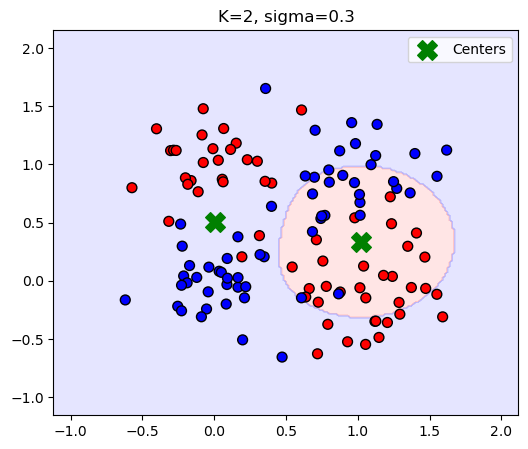

C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


when sigma is 0.3 and k is 3 the accuracy is 0.76 
[[47 13]
 [16 44]]


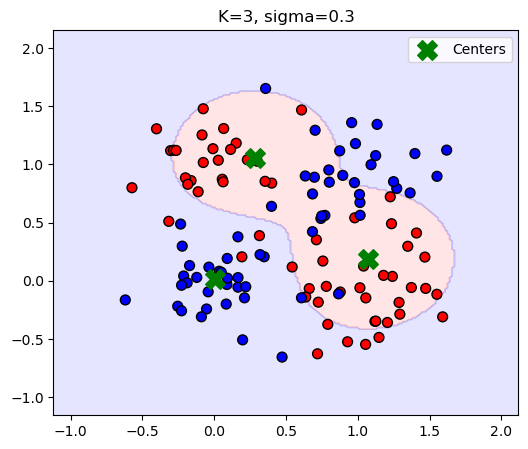

C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


when sigma is 0.3 and k is 4 the accuracy is 0.88 
[[51  9]
 [ 5 55]]


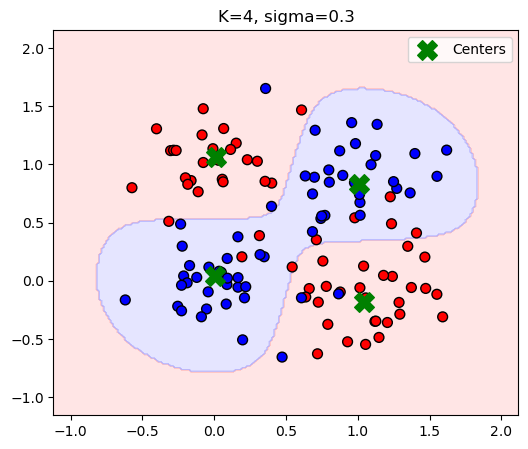

C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


when sigma is 0.7 and k is 2 the accuracy is 0.55 
[[33 27]
 [27 33]]


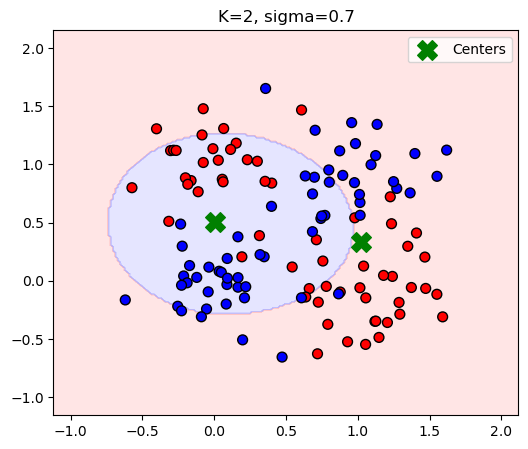

C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


when sigma is 0.7 and k is 3 the accuracy is 0.62 
[[44 16]
 [29 31]]


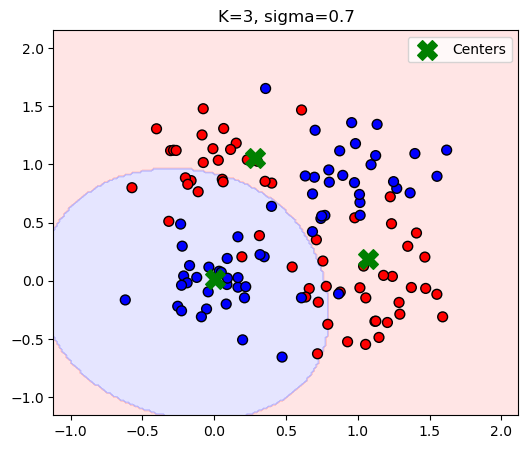

C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SAM\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


when sigma is 0.7 and k is 4 the accuracy is 0.89 
[[51  9]
 [ 4 56]]


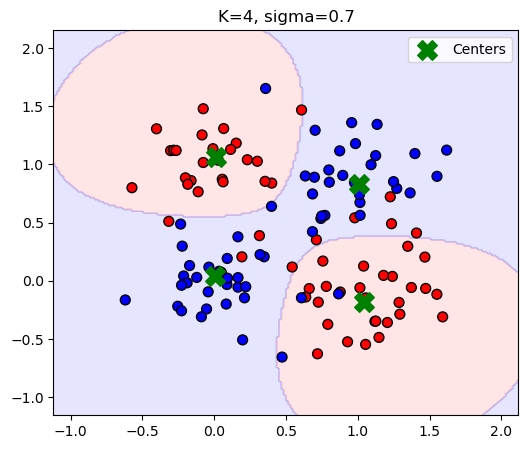

In [27]:
from sklearn.metrics import confusion_matrix
K_values = [2, 3, 4]
sigma_values = [0.3, 0.7]


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


for sigma in sigma_values:
    for K in K_values:
        kmeans = KMeans(n_clusters=K, random_state=0)
        kmeans.fit(X)
        centers = kmeans.cluster_centers_
        Phi = build_Phi(X, centers, sigma)
        w = compute_weights(Phi, y)
        y_pred = (w @ Phi >= 0.5).astype(int)
        acc = accuracy(y, y_pred)
        print(f"when sigma is {sigma} and k is {K} the accuracy is {acc:.2f} ")
        print(confusion_matrix(y, y_pred))
        plot_decision_boundary(X, y, centers, sigma, w,
                               title=f"K={K}, sigma={sigma}")


The decision boundary for k = 4 appears better, because k = 4 provides enough RBF centers to represent the underlying structure of data. And we have two cases when k =4, one is when $\sigma = 0.3$ and two is when $\sigma=0.7$. To compare these two cases, we computed the classification accuracy and the confusion matrix.The numerical results show that the model with k= 4 and $\sigma=0.7$ achieves higher accuracy and makes fewer misclassifications compared to the case with $\sigma=0.3$.

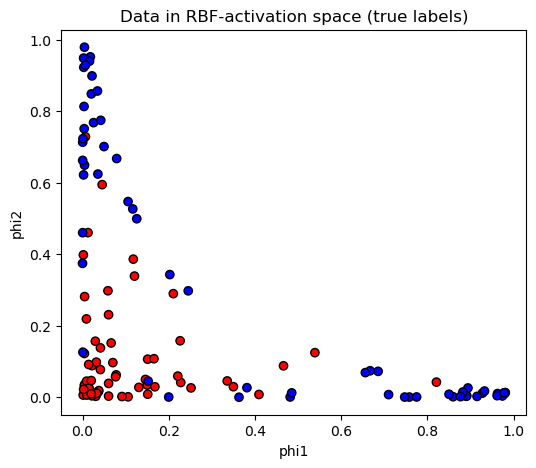

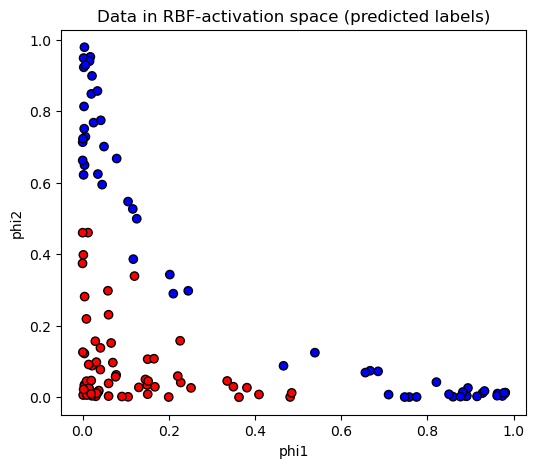

In [18]:
centers_fixed = np.array([[0,0], [1,1]])
sigma_fixed = 0.45
Phi_fixed = build_Phi(X, centers_fixed, sigma_fixed)
w_fixed = compute_weights(Phi_fixed, y)
y_pred_fixed = (w_fixed @ Phi_fixed >= 0.5).astype(int)


plt.figure(figsize=(6,5))
plt.scatter(Phi_fixed[1,:], Phi_fixed[2,:], c=y, cmap=ListedColormap(['#FF0000','#0000FF']), edgecolor='k')
plt.xlabel('phi1')
plt.ylabel('phi2')
plt.title('Data in RBF-activation space (true labels)')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Phi_fixed[1,:], Phi_fixed[2,:], c=y_pred_fixed, cmap=ListedColormap(['#FF0000','#0000FF']), edgecolor='k')
plt.xlabel('phi1')
plt.ylabel('phi2')
plt.title('Data in RBF-activation space (predicted labels)')
plt.show()


In the first plot, the points are colored according to their true class labels. In the second plot, points are colored according to the predicted labels after training the RBF network. Comparing this plot with the true-label plot allows us to identify any misclassifications.
The network predicted correctly the class of points whose color matches in both plots. And the network predicted incorrectly the class of points whose color is different in two plots. We can see that mostly the class of points are correctly predicted by RBF network.